In [1]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/viacheslavkrutoyatov/x5-hse-2/train_2.csv')

In [2]:
df.head()

,new_id,Год,Месяц,Среднее количество промо товаров в чеке,Среднее количество товаров в чеке,Среднее количество отмен,Рабочие часы в день,"Дата открытия, категориальный","Торговая площадь, категориальный",Населенный пункт,...,"Трафик авто, в час","Маркетплейсы, доставки, постаматы (100 м)",Медицинские уч. и аптеки (300 м),Школы (300 м),Остановки (300 м),Продуктовые магазины (500 м),Пятерочки (500 м),Количество касс,Флаг алкогольной лицензии,РТО
0,0,2024,1,1.08,6.03,147.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,75147744.85
1,0,2023,1,1.32,6.04,162.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74914754.22
2,0,2025,1,0.82,6.00,145.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,87125506.92
3,0,2025,2,0.90,6.00,118.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,82659801.63
4,0,2024,2,1.25,6.06,154.0,16.0,Новый,Большой,Ярославль г,...,73,1,0,0,0,3,1,10,1,74209339.11


EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 485082 entries, 0 to 485081
Data columns (total 24 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   new_id                                     485082 non-null  int64  
 1   Год                                        485082 non-null  int64  
 2   Месяц                                      485082 non-null  int64  
 3   Среднее количество промо товаров в чеке    485082 non-null  float64
 4   Среднее количество товаров в чеке          485082 non-null  float64
 5   Среднее количество отмен                   485082 non-null  float64
 6   Рабочие часы в день                        485082 non-null  float64
 7   Дата открытия, категориальный              485082 non-null  object 
 8   Торговая площадь, категориальный           485082 non-null  object 
 9   Населенный пункт                           485082 non-null  object 
 10  Регион  

In [4]:
print(df['РТО'].describe())
print(df['РТО'].skew())

count    4.850820e+05
mean     8.853480e+07
std      4.824900e+07
min      1.179116e+06
25%      5.627279e+07
50%      7.521094e+07
75%      1.057677e+08
max      6.557204e+08
Name: РТО, dtype: float64
1.9860235779446298


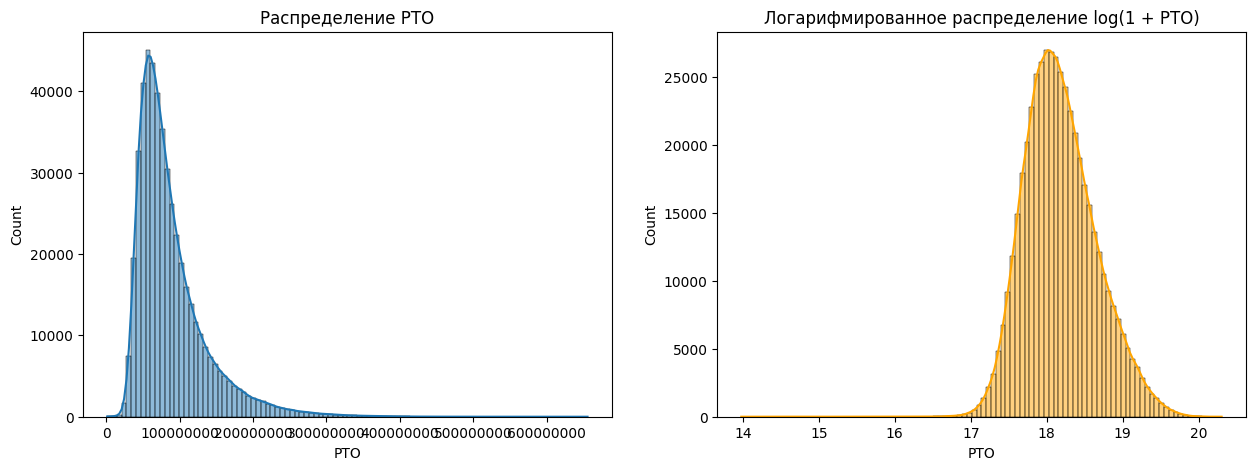

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(df['РТО'], bins=100, kde=True, ax=axes[0])
axes[0].set_title('Распределение РТО')
axes[0].ticklabel_format(style='plain')

sns.histplot(np.log1p(df['РТО']), bins=100, kde=True, ax=axes[1], color='orange')
axes[1].set_title('Логарифмированное распределение log(1 + РТО)')

plt.show()

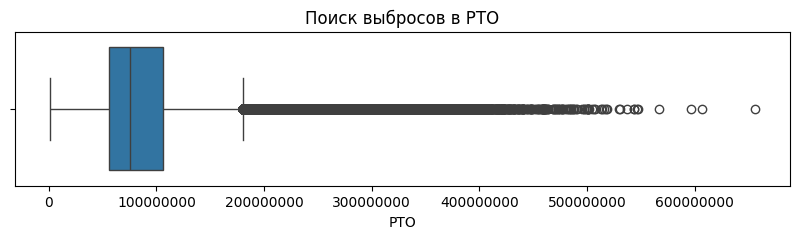

,new_id,Год,Месяц,РТО
216809,9754,2023,10,6.557204e+08
142236,6389,2024,8,6.069936e+08
142235,6389,2024,7,5.965186e+08
285182,12812,2024,7,5.667146e+08
285180,12812,2024,6,5.474707e+08
130779,5884,2024,12,5.466047e+08
469340,21032,2024,7,5.436554e+08
322061,14419,2024,12,5.432477e+08
71931,3241,2024,7,5.368106e+08
148433,6673,2024,12,5.308997e+08


In [6]:
plt.figure(figsize=(10, 2))
sns.boxplot(x=df['РТО'])
plt.ticklabel_format(style='plain', axis='x')
plt.title('Поиск выбросов в РТО')
plt.show()

display(df.nlargest(10, 'РТО')[['new_id', 'Год', 'Месяц', 'РТО']])

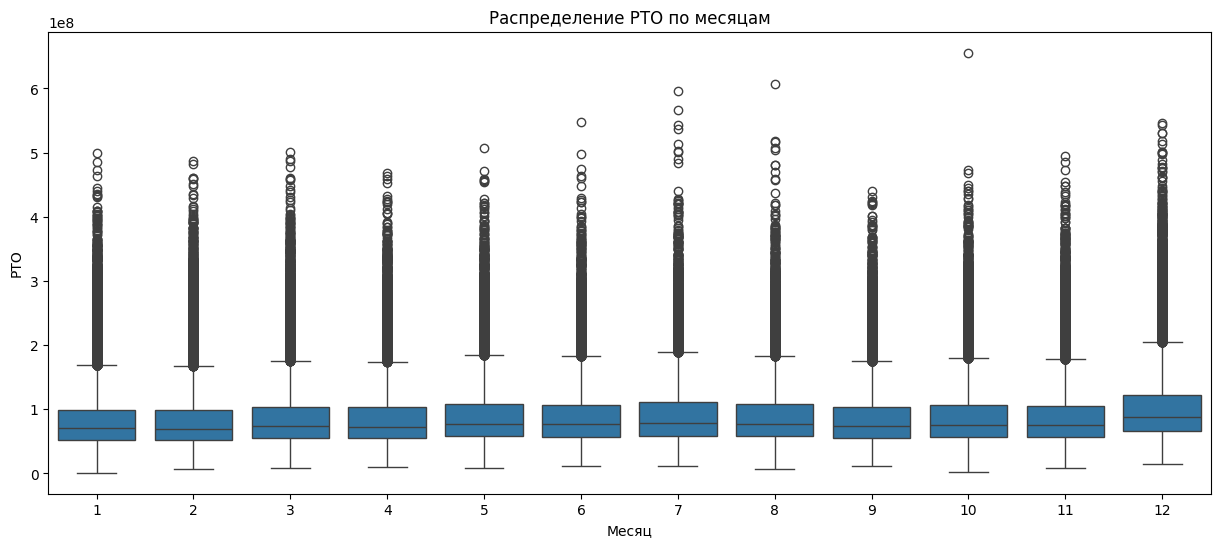

In [7]:
plt.figure(figsize=(15, 6))
sns.boxplot(data=df, x='Месяц', y='РТО')
plt.title('Распределение РТО по месяцам')
plt.show()

In [8]:
import pandas as pd
import numpy as np

print(f"new_id: {df['new_id'].nunique()}")
print(f"Year range: {df['Год'].min()} - {df['Год'].max()}")
print(f"Months in dataset: {sorted(df['Месяц'].unique())}")

history_len = df.groupby('new_id').size()
print(f"\nHistory per store:")
print(f"  min months: {history_len.min()}")
print(f"  mean months: {history_len.mean():.1f}")
print(f"  max months: {history_len.max()}")

print(f"\nRTO stats:")
print(f"  min RTO: {df['РТО'].min():.2f}")
print(f"  RTO <= 0: {(df['РТО'] <= 0).sum()}")
print(f"  RTO NaN: {df['РТО'].isna().sum()}")

cols_to_check = ['Среднее количество товаров в чеке', 
                 'Среднее количество промо товаров в чеке', 
                 'Среднее количество отмен', 
                 'Рабочие часы в день']
print(f"\nFeature stats:")
print(df[cols_to_check].describe().round(2))

new_id: 18657
Year range: 2023 - 2025
Months in dataset: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

History per store:
  min months: 26
  mean months: 26.0
  max months: 26

RTO stats:
  min RTO: 1179116.01
  RTO <= 0: 0
  RTO NaN: 0

Feature stats:
       Среднее количество товаров в чеке  \
count                          485082.00   
mean                                5.28   
std                                 1.05   
min                                 1.65   
25%                                 4.55   
50%                                 5.13   
75%                                 5.85   
max                                23.49   

       Среднее количество промо товаров в чеке  Среднее количество отмен  \
count                                485082.00                 485082.00   
mean                                      0.96                    273.60   
std    

In [9]:
print("Stores with working hours > 24:")
print(df[df['Рабочие часы в день'] > 24][['new_id', 'Год', 'Месяц', 'Рабочие часы в день', 'Количество касс', 'РТО']].head())

print("\nTop-5 cancellations:")
print(df.nlargest(5, 'Среднее количество отмен')[['new_id', 'Год', 'Месяц', 'Среднее количество отмен', 'РТО']])


Stores with working hours > 24:
      new_id   Год  Месяц  Рабочие часы в день  Количество касс          РТО
3198     136  2024      1                 26.0                6  40783684.51
3199     136  2025      1                 26.0                6  80076029.91
3200     136  2023      1                 26.0                6  57781095.48
3201     136  2023      2                 26.0                6  56534402.67
3202     136  2025      2                 26.0                6  79995856.27

Top-5 cancellations:
        new_id   Год  Месяц  Среднее количество отмен           РТО
303474   13611  2023      1                   22507.0  8.478739e+07
142235    6389  2024      7                    9789.0  5.965186e+08
142236    6389  2024      8                    8478.0  6.069936e+08
142233    6389  2024      6                    7684.0  4.603767e+08
103599    4667  2024      7                    7089.0  3.771696e+08


In [10]:
import pandas as pd
import numpy as np

df.loc[df['Рабочие часы в день'] > 24, 'Рабочие часы в день'] = 24.0

pivot_rto = df.pivot_table(index='Месяц', columns='Год', values='РТО', aggfunc='mean')
print(pivot_rto)

print("\nMarch coefficient (Feb -> Mar):")
if 2023 in pivot_rto.columns and 2024 in pivot_rto.columns:
    print(f"  2023: {pivot_rto.loc[3, 2023] / pivot_rto.loc[2, 2023]:.3f}")
    print(f"  2024: {pivot_rto.loc[3, 2024] / pivot_rto.loc[2, 2024]:.3f}")

feb_2025 = df[(df['Год'] == 2025) & (df['Месяц'] == 2)]
jan_2023 = df[(df['Год'] == 2023) & (df['Месяц'] == 1)]

store_growth = feb_2025.set_index('new_id')['РТО'] / jan_2023.set_index('new_id')['РТО']
print("\nStore growth quantiles (2-year):")
print(store_growth.quantile([0.05, 0.25, 0.5, 0.75, 0.95]))

df['promo_share'] = df['Среднее количество промо товаров в чеке'] / (df['Среднее количество товаров в чеке'] + 1e-5)
print("\nAvg promo share by month:")
print(df.groupby('Месяц')['promo_share'].mean())


Год            2023          2024          2025
Месяц                                          
1      7.294137e+07  8.250019e+07  9.414061e+07
2      7.110712e+07  8.450857e+07  9.171339e+07
3      8.023747e+07  9.379216e+07           NaN
4      8.040807e+07  9.216413e+07           NaN
5      8.441712e+07  9.714561e+07           NaN
6      8.284801e+07  9.588640e+07           NaN
7      8.538163e+07  9.879009e+07           NaN
8      8.449562e+07  9.545146e+07           NaN
9      8.123091e+07  9.119891e+07           NaN
10     8.406210e+07  9.432789e+07           NaN
11     8.289331e+07  9.406005e+07           NaN
12     9.706895e+07  1.091336e+08           NaN

March coefficient (Feb -> Mar):
  2023: 1.128
  2024: 1.110

Store growth quantiles (2-year):
0.05    0.922257
0.25    1.118111
0.50    1.251276
0.75    1.405245
0.95    1.764770
Name: РТО, dtype: float64

Avg promo share by month:
Месяц
1     0.164645
2     0.184616
3     0.211957
4     0.217012
5     0.204208
6     0.182932

In [11]:
def generate_advanced_features(df):
    df = df.copy()
    df.loc[df['Рабочие часы в день'] > 24, 'Рабочие часы в день'] = 24.0
    
    df = df.sort_values(by=['new_id', 'Год', 'Месяц']).reset_index(drop=True)
    
    df['promo_share'] = df['Среднее количество промо товаров в чеке'] / (df['Среднее количество товаров в чеке'] + 1e-5)
    df['cancellations_per_hour'] = df['Среднее количество отмен'] / (df['Рабочие часы в день'] + 1e-5)
    
    df['lag_1'] = df.groupby('new_id')['РТО'].shift(1)
    df['lag_2'] = df.groupby('new_id')['РТО'].shift(2)
    df['lag_3'] = df.groupby('new_id')['РТО'].shift(3)
    
    df['lag_12'] = df.groupby('new_id')['РТО'].shift(12)
    df['lag_13'] = df.groupby('new_id')['РТО'].shift(13)
    df['lag_24'] = df.groupby('new_id')['РТО'].shift(24)
    
    df['historical_march_bump'] = df['lag_12'] / (df['lag_13'] + 1e-5)
    
    df['feb_yoy_momentum'] = df['lag_1'] / (df['lag_13'] + 1e-5)
    
    df['trend_1m'] = df['lag_1'] / (df['lag_2'] + 1e-5)
    
    df['promo_share_lag_1'] = df.groupby('new_id')['promo_share'].shift(1)
    df['promo_share_lag_12'] = df.groupby('new_id')['promo_share'].shift(12)
    
    df['cancellations_lag_1'] = df.groupby('new_id')['cancellations_per_hour'].shift(1)
    
    df['mean_3m'] = df.groupby('new_id')['lag_1'].rolling(window=3).mean().reset_index(level=0, drop=True)
    
    return df

df_features = generate_advanced_features(df)


In [12]:
import pandas as pd
import numpy as np

print("Checking geo features for static nature:")

geo_cols = ['Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 'Пятерочки (500 м)']
geo_stats = df_features.groupby('new_id')[geo_cols].nunique().mean()
print(geo_stats)

print("\nCorrelation with March 2024 bump:")
march_24 = df_features[(df_features['Год'] == 2024) & (df_features['Месяц'] == 3)].copy()

march_24['real_march_bump'] = march_24['РТО'] / (march_24['lag_1'] + 1e-5)

cols_to_corr = ['Численность населения', 'Количество домохозяйств', 'Трафик пеший, в час', 
                'Трафик авто, в час', 'Пятерочки (500 м)', 'Продуктовые магазины (500 м)']
print(march_24[cols_to_corr].corrwith(march_24['real_march_bump']).round(4))

print("\nTop-10 regions by March bump:")
print(march_24.groupby('Регион')['real_march_bump'].mean().sort_values(ascending=False).head(10))


Checking geo features for static nature:
Численность населения      1.0
Количество домохозяйств    1.0
Трафик пеший, в час        1.0
Пятерочки (500 м)          1.0
dtype: float64

Correlation with March 2024 bump:
Численность населения           0.0198
Количество домохозяйств        -0.0652
Трафик пеший, в час            -0.0497
Трафик авто, в час              0.0171
Пятерочки (500 м)              -0.0631
Продуктовые магазины (500 м)   -0.0747
dtype: float64

Top-10 regions by March bump:
Регион
Мордовия Респ        1.187181
Алтай Респ           1.143270
Ленинградская обл    1.139950
Московская обл       1.136522
Хакасия Респ         1.134744
Оренбургская обл     1.131947
Москва г             1.130805
Марий Эл Респ        1.129355
Смоленская обл       1.127316
Костромская обл      1.126616
Name: real_march_bump, dtype: float64


In [47]:
import pandas as pd
import numpy as np
import calendar

def preprocess_and_generate_features(df):
    data = df.copy()

    data['Рабочие часы в день'] = data['Рабочие часы в день'].clip(upper=24)
    cancel_q99 = data['Среднее количество отмен'].quantile(0.99)
    data['Среднее количество отмен'] = data['Среднее количество отмен'].clip(upper=cancel_q99)

    rto_pivot = data.pivot(index='new_id', columns=['Год', 'Месяц'], values='РТО')
    
    static_cols = [
        'new_id', 'Регион', 'Населенный пункт', 'Дата открытия, категориальный',
        'Торговая площадь, категориальный', 'Численность населения', 'Количество домохозяйств',
        'Трафик пеший, в час', 'Трафик авто, в час', 'Маркетплейсы, доставки, постаматы (100 м)',
        'Медицинские уч. и аптеки (300 м)', 'Школы (300 м)', 'Остановки (300 м)',
        'Продуктовые магазины (500 м)', 'Пятерочки (500 м)', 'Количество касс', 'Флаг алкогольной лицензии'
    ]
    store_info = data[static_cols].drop_duplicates(subset=['new_id']).set_index('new_id')

    def build_dataset_for_march(target_year):
        base_year = target_year
        prev_year = target_year - 1
        
        df_features = store_info.copy()
        
        # Индексы изначально выровнены по new_id
        df_features['RTO_base_Feb'] = rto_pivot[(base_year, 2)]
        df_features['RTO_base_Jan'] = rto_pivot[(base_year, 1)]
        df_features['RTO_prev_Mar'] = rto_pivot[(prev_year, 3)]
        df_features['RTO_prev_Feb'] = rto_pivot[(prev_year, 2)]
        df_features['RTO_base_Dec'] = rto_pivot[(base_year - 1, 12)] if (base_year - 1, 12) in rto_pivot.columns else np.nan
        
        df_features['jan_dec_drop'] = df_features['RTO_base_Jan'] / df_features['RTO_base_Dec']
        df_features['feb_dec_ratio'] = df_features['RTO_base_Feb'] / df_features['RTO_base_Dec']
        df_features['hist_march_bump'] = df_features['RTO_prev_Mar'] / df_features['RTO_prev_Feb']
        df_features['regional_march_bump'] = df_features.groupby('Регион')['hist_march_bump'].transform('mean')
        df_features['store_growth_1y'] = df_features['RTO_base_Feb'] / df_features['RTO_prev_Feb']
        df_features['recent_trend_1m'] = df_features['RTO_base_Feb'] / df_features['RTO_base_Jan']
        
        regional_mean_rto = df_features.groupby('Регион')['RTO_base_Feb'].transform('mean')
        df_features['rto_vs_region_mean'] = df_features['RTO_base_Feb'] / regional_mean_rto

        feb_stats = data[(data['Год'] == base_year) & (data['Месяц'] == 2)].set_index('new_id')
        df_features['Feb_promo_share'] = feb_stats['Среднее количество промо товаров в чеке'] / feb_stats['Среднее количество товаров в чеке']
        df_features['Feb_cancels'] = feb_stats['Среднее количество отмен']
        df_features['Feb_work_hours'] = feb_stats['Рабочие часы в день']

        df_features['organic_trend_index'] = df_features['recent_trend_1m'] / (df_features['Feb_promo_share'] + 0.01)
        
        total_traffic = df_features['Трафик пеший, в час'] + df_features['Трафик авто, в час'] + 1
        df_features['tills_per_traffic'] = df_features['Количество касс'] / total_traffic
        df_features['scaled_march_bump'] = df_features['hist_march_bump'] * df_features['store_growth_1y']
        
        # Фильтрация истории ДО целевого марта
        history_before_target = data[(data['Год'] * 12 + data['Месяц']) <= (base_year * 12 + 2)]
        
        # БЕЗОПАСНОЕ ДОБАВЛЕНИЕ СЛОЖНЫХ ФИЧ (без использования .merge())
        # 1. Возраст магазина
        df_features['store_age_months'] = history_before_target.groupby('new_id').size()
        df_features['store_age_months'] = df_features['store_age_months'].fillna(0)
        df_features['is_new_store'] = (df_features['store_age_months'] <= 6).astype(int)
        
        # 2. Недавняя волатильность за 3 месяца
        recent_3m = history_before_target[(history_before_target['Год'] * 12 + history_before_target['Месяц']) > (base_year * 12 - 1)]
        df_features['rto_roll_std_3m'] = recent_3m.groupby('new_id')['РТО'].std()
        df_features['rto_roll_std_3m'] = df_features['rto_roll_std_3m'].fillna(0)
        
        # 3. Емкость касс и коэффициент дней
        df_features['rto_per_cashbox'] = df_features['RTO_base_Feb'] / (df_features['Количество касс'] + 1)
        
        days_in_march = 31
        days_in_feb = calendar.monthrange(base_year, 2)[1]
        df_features['calendar_days_ratio'] = days_in_march / days_in_feb

        def count_weekends(yr, mo):
            # Считаем количество Сб и Вс в месяце
            days = pd.date_range(start=f'{yr}-{mo:02d}-01', end=f'{yr}-{mo:02d}-{calendar.monthrange(yr, mo)[1]}')
            return np.sum(days.weekday >= 5) # 5 - Суббота, 6 - Воскресенье 

        # 2. Календарь: Отношение истинных выходных дней (Суббота + Воскресенье)
        weekends_mar = count_weekends(base_year, 3)
        weekends_feb = count_weekends(base_year, 2)
        df_features['weekend_days_ratio'] = weekends_mar / weekends_feb

        # 3. Эффективность трафика и конверсии
        total_traffic = df_features['Трафик пеший, в час'] + df_features['Трафик авто, в час'] + 1
        df_features['rto_to_traffic_ratio'] = df_features['RTO_base_Feb'] / total_traffic
        df_features['traffic_per_cashbox'] = total_traffic / (df_features['Количество касс'] + 1)

        # 4. Конкурентная среда и инфраструктурная плотность
        df_features['pure_competitors_500m'] = df_features['Продуктовые магазины (500 м)'] - df_features['Пятерочки (500 м)']
        df_features['infrastructure_density'] = (
            df_features['Медицинские уч. и аптеки (300 м)'] + 
            df_features['Школы (300 м)'] + 
            df_features['Остановки (300 м)']
        )

        df_features['region_alcohol'] = df_features['Регион'].astype(str) + "_" + df_features['Флаг алкогольной лицензии'].astype(str)

        # Определяем количество дней в феврале (учитываем високосный 2024 год!)
        days_in_feb = calendar.monthrange(base_year, 2)[1]
        days_in_mar = 31
        
        # 1. Выручка в день (Run-Rate) — адаптация топ-1 фичи коллеги
        df_features['feb_rto_per_day'] = df_features['RTO_base_Feb'] / days_in_feb
        
        # Проецируем февральскую скорость на 31 день марта 
        # (calendar_growth_factor убрали, так как это дубликат calendar_days_ratio)
        df_features['projected_mar_rto'] = df_features['feb_rto_per_day'] * days_in_mar

        # 2. Логарифм выручки
        df_features['log_rto_feb'] = np.log1p(df_features['RTO_base_Feb'])
        
        # 3. Выручка на домохозяйство
        df_features['rto_per_household'] = df_features['RTO_base_Feb'] / (df_features['Количество домохозяйств'] + 1)

        # 4. Возраст магазина (БЕЗОПАСНЫЙ РАСЧЕТ)
        # Убедитесь, что колонка называется именно так, как она лежит в df_features
        df_features['store_age_months_exact'] = (pd.to_datetime(f'{base_year}-03-01') - pd.to_datetime(df_features['Дата открытия, категориальный'], format='mixed', errors='coerce')).dt.days / 30.44
        df_features['store_age_months_exact'] = df_features['store_age_months_exact'].fillna(0) # Защита от пустых дат

        # Расчет целевой переменной — теперь индексы идеально сопоставлены
        if target_year == 2025:
            target = None
        else:
            target_rto = rto_pivot[(target_year, 3)]
            target = target_rto / df_features['RTO_base_Feb']

        return df_features, target

    X_train, y_train = build_dataset_for_march(target_year=2024)
    X_test, _ = build_dataset_for_march(target_year=2025)
    
    return X_train, y_train, X_test

X_train, y_train, X_test = preprocess_and_generate_features(df)

In [48]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

cat_features = ['Регион', 'Населенный пункт', 'Дата открытия, категориальный', 'Торговая площадь, категориальный', 'region_alcohol']
for col in cat_features:
    X_train[col] = X_train[col].fillna('Unknown').astype(str)
    X_test[col] = X_test[col].fillna('Unknown').astype(str)

# 3. Отделяем таргет-образующие лаги
cols_to_drop = ['RTO_base_Feb', 'RTO_base_Jan', 'RTO_base_Dec', 'RTO_prev_Mar', 'RTO_prev_Feb']
X_train_pure = X_train.drop(columns=cols_to_drop)
X_test_pure = X_test.drop(columns=cols_to_drop)

# 4. ЗАЩИТА: Синхронная очистка X и y от NaN и Inf в таргете
good_rows = np.isfinite(y_train) & (X_train['RTO_base_Feb'] > 0)
X_train_pure = X_train_pure[good_rows]
y_train = y_train[good_rows]

# 5. Валидационный сплит (теперь размеры совпадут на 100%)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pure, y_train, 
    test_size=0.15, 
    random_state=42 
)


model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    loss_function='MAE',
    eval_metric='MAE',
    random_seed=42,
    early_stopping_rounds=150,
    verbose=100
)

model.fit(
    X_tr, y_tr,
    cat_features=cat_features,
    eval_set=(X_val, y_val),
    plot=False 
)

print(f"Лучшая итерация: {model.best_iteration_}")
print(f"MAE на валидации: {model.best_score_['validation']['MAE']:.5f}")

predicted_coefs = model.predict(X_test_pure)

final_rto_predictions = predicted_coefs * X_test['RTO_base_Feb']
final_rto_predictions = final_rto_predictions.clip(lower=X_test['RTO_base_Feb'].min())

final_rto_predictions = np.maximum(final_rto_predictions, X_test['RTO_base_Feb'] * 0.8)
final_rto_predictions = np.minimum(final_rto_predictions, X_test['RTO_base_Feb'] * 1.8)

0:	learn: 0.0452696	test: 0.0426861	best: 0.0426861 (0)	total: 26ms	remaining: 51.9s
100:	learn: 0.0377048	test: 0.0375468	best: 0.0375468 (100)	total: 2.26s	remaining: 42.5s
200:	learn: 0.0360210	test: 0.0370859	best: 0.0370859 (200)	total: 4.42s	remaining: 39.6s
300:	learn: 0.0351089	test: 0.0369412	best: 0.0369402 (299)	total: 6.63s	remaining: 37.4s
400:	learn: 0.0343066	test: 0.0368416	best: 0.0368371 (389)	total: 8.84s	remaining: 35.3s
500:	learn: 0.0336023	test: 0.0367871	best: 0.0367847 (494)	total: 11.1s	remaining: 33.1s
600:	learn: 0.0330384	test: 0.0367424	best: 0.0367418 (597)	total: 13.4s	remaining: 31.1s
700:	learn: 0.0325477	test: 0.0367683	best: 0.0367285 (610)	total: 15.6s	remaining: 28.8s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.03672854669
bestIteration = 610

Shrink model to first 611 iterations.
Лучшая итерация: 610
MAE на валидации: 0.03673


In [49]:
# submission = pd.DataFrame({
#     'new_id': X_test.index,
#     'rto': final_rto_predictions.values
# })
# submission['rto'] = submission['rto'].clip(lower=X_test['RTO_base_Feb'].min())
# submission.to_csv('catboost_pure_mom.csv', index=False)

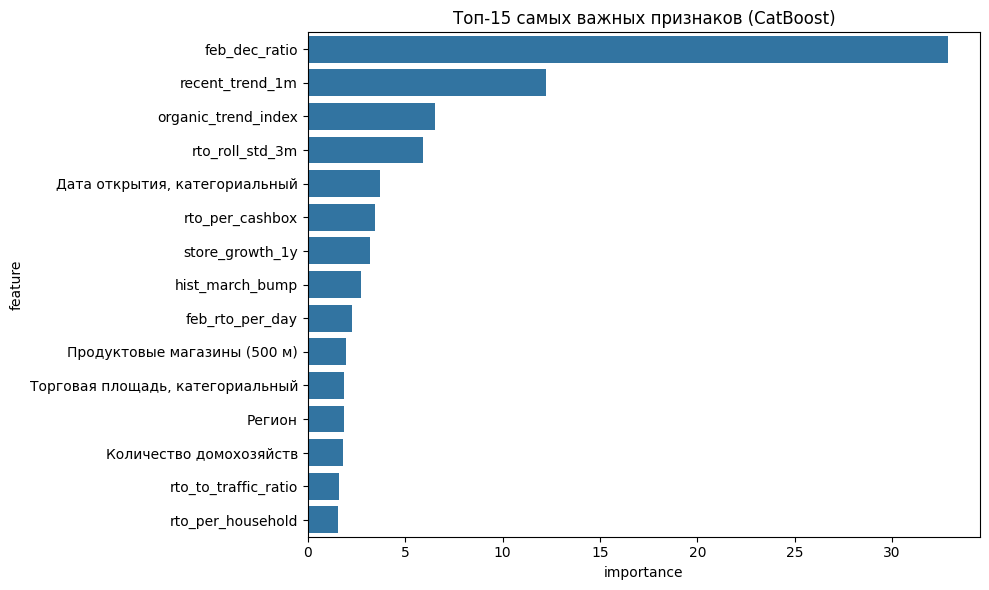

                          feature  importance
17                  feb_dec_ratio   32.869452
21                recent_trend_1m   12.256069
26            organic_trend_index    6.517743
31                rto_roll_std_3m    5.912680
2   Дата открытия, категориальный    3.706624
32                rto_per_cashbox    3.464883
20                store_growth_1y    3.202611
18                hist_march_bump    2.754390
40                feb_rto_per_day    2.266625
12   Продуктовые магазины (500 м)    1.940045


In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Достаем важность признаков
feature_importances = pd.DataFrame({
    'feature': model.feature_names_,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

# Строим красивый график
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importances.head(15), x='importance', y='feature')
plt.title('Топ-15 самых важных признаков (CatBoost)')
plt.tight_layout()
plt.show()

print(feature_importances.head(10))

In [51]:
from sklearn.model_selection import KFold
import numpy as np


kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_predictions = np.zeros(len(X_train_pure))
test_predictions = np.zeros(len(X_test_pure))

fold_scores = []

print("Начинаем 5-Fold кросс-валидацию...")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_pure)):
    # Нарезаем данные на текущий фолд
    X_tr, y_tr = X_train_pure.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train_pure.iloc[val_idx], y_train.iloc[val_idx]
    
    model = CatBoostRegressor(
        iterations=5000,           # Даем еще небольшой запас хода
        learning_rate=0.018,       # Слегка уменьшаем шаг для более плавной сходимости
        depth=6,                   
        l2_leaf_reg=7,             # Подняли с 5 до 7 для борьбы с шумом (спасет Fold 3)
        random_strength=2.0,       # Увеличили агрессивность случайности с 1.5 до 2.0
        colsample_bylevel=0.85,    # Модель выбирает подмножество фич (защита от оверфита)
        loss_function='MAE',
        eval_metric='MAE',
        random_seed=42,   
        early_stopping_rounds=250, # Расширили окно ожидания
        verbose=0                
    )
    
    model.fit(
        X_tr, y_tr,
        cat_features=cat_features,
        eval_set=(X_val, y_val)
    )
    
    val_preds = model.predict(X_val)
    oof_predictions[val_idx] = val_preds
    
    fold_mae = model.best_score_['validation']['MAE']
    fold_scores.append(fold_mae)
    print(f"Fold {fold + 1} | Лучшая итерация: {model.best_iteration_} | MAE: {fold_mae:.5f}")
    
    test_predictions += model.predict(X_test_pure) / 5

mean_oof_mae = np.mean(fold_scores)
print(f"ИТОГОВЫЙ LOCAL MAE (OOF): {mean_oof_mae:.5f}")

Начинаем 5-Fold кросс-валидацию...
Fold 1 | Лучшая итерация: 2449 | MAE: 0.03542
Fold 2 | Лучшая итерация: 4639 | MAE: 0.03534
Fold 3 | Лучшая итерация: 3429 | MAE: 0.03831
Fold 4 | Лучшая итерация: 4114 | MAE: 0.03649
Fold 5 | Лучшая итерация: 2167 | MAE: 0.03534
ИТОГОВЫЙ LOCAL MAE (OOF): 0.03618


In [52]:
import lightgbm as lgb
import pandas as pd
import numpy as np
import re
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore') # Скрываем лишние предупреждения LightGBM

print("Очищаем названия признаков от спецсимволов...")

# 1. Функция для удаления запятых, скобок и спецсимволов
def clean_names(name):
    return re.sub(r'[^A-Za-z0-9_А-Яа-яЁё]', '_', name).strip('_')

X_train_lgb = X_train_pure.copy()
X_test_lgb = X_test_pure.copy()

# Переименовываем колонки в датафреймах
X_train_lgb.rename(columns=clean_names, inplace=True)
X_test_lgb.rename(columns=clean_names, inplace=True)

# Обязательно обновляем список категориальных фич, так как имена изменились!
clean_cat_features = [clean_names(col) for col in cat_features]

# Переводим категориальные колонки в нужный тип
for col in clean_cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_oof_predictions = np.zeros(len(X_train_lgb))
lgb_test_predictions = np.zeros(len(X_test_lgb))
lgb_fold_scores = []

print("Начинаем 5-Fold кросс-валидацию LightGBM...")

# Используем тот же kf (KFold), что и для CatBoost!
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_lgb)):
    X_tr, y_tr = X_train_lgb.iloc[train_idx], y_train.iloc[train_idx]
    X_val, y_val = X_train_lgb.iloc[val_idx], y_train.iloc[val_idx]
    
    # Настраиваем гиперпараметры под наш датасет
    model_lgb = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.015,
        num_leaves=31,             
        max_depth=6,               
        min_child_samples=20,      
        subsample=0.8,
        colsample_bytree=0.85,     
        reg_alpha=1.0,             
        reg_lambda=5.0,            
        objective='regression_l1', # MAE лосс
        metric='mae',
        random_state=42,
        n_jobs=-1,
        verbose=-1                 # Отключаем спам в консоль
    )
    
    callbacks = [lgb.early_stopping(stopping_rounds=250, verbose=False)]
    
    model_lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        categorical_feature=clean_cat_features, # Используем очищенный список
        callbacks=callbacks
    )
    
    val_preds = model_lgb.predict(X_val)
    lgb_oof_predictions[val_idx] = val_preds
    
    fold_mae = mean_absolute_error(y_val, val_preds)
    lgb_fold_scores.append(fold_mae)
    print(f"Fold {fold + 1} | Лучшая итерация: {model_lgb.best_iteration_} | MAE: {fold_mae:.5f}")
    
    lgb_test_predictions += model_lgb.predict(X_test_lgb) / 5

print(f"ИТОГОВЫЙ LIGHTGBM MAE (OOF): {np.mean(lgb_fold_scores):.5f}")

Очищаем названия признаков от спецсимволов...
Начинаем 5-Fold кросс-валидацию LightGBM...
Fold 1 | Лучшая итерация: 2399 | MAE: 0.03582
Fold 2 | Лучшая итерация: 3107 | MAE: 0.03609
Fold 3 | Лучшая итерация: 2620 | MAE: 0.03874
Fold 4 | Лучшая итерация: 2119 | MAE: 0.03710
Fold 5 | Лучшая итерация: 3415 | MAE: 0.03592
ИТОГОВЫЙ LIGHTGBM MAE (OOF): 0.03673


In [53]:
print("\nСмешиваем прогнозы CatBoost и LightGBM...")

blended_oof = (oof_predictions * 0.73) + (lgb_oof_predictions * 0.27)
blend_oof_mae = mean_absolute_error(y_train, blended_oof)
print(f"МАГИЯ АНСАМБЛЯ! OOF MAE Бленда: {blend_oof_mae:.5f}")


Смешиваем прогнозы CatBoost и LightGBM...
МАГИЯ АНСАМБЛЯ! OOF MAE Бленда: 0.03610


In [ ]:
# Смешиваем прогнозы для тестовой выборки
blended_test_preds = (test_predictions * 0.6) + (lgb_test_predictions * 0.4)

# Переводим в РТО
final_blended_rto = blended_test_preds * X_test['RTO_base_Feb']

# Формируем итоговый датафрейм
submission_blend = pd.DataFrame({
    'new_id': X_test.index,
    'rto': final_blended_rto.values
})

# Защита от отрицательных значений
submission_blend['rto'] = submission_blend['rto'].clip(lower=X_test['RTO_base_Feb'].min())

# Сохраняем
submission_blend.to_csv('blend_catboost_lightgbm.csv', index=False)

In [44]:
final_rto_predictions = test_predictions * X_test['RTO_base_Feb']

submission = pd.DataFrame({
    'new_id': X_test.index,
    'rto': final_rto_predictions.values
})
submission['rto'] = submission['rto'].clip(lower=X_test['RTO_base_Feb'].min())
submission.to_csv('catboost_cv5_mom_new_features.csv', index=False)